# Portfolio Management Fundamentals
### A ground-up guide for quant developer interviews — CS background assumed, finance background not

---

This notebook covers:
1. Financial assets and returns
2. Core statistics (mean, variance, covariance, correlation)
3. The covariance matrix Σ and portfolio variance
4. Mean-Variance Optimization (MVO) — full derivation
5. CAPM and the Security Market Line
6. Black-Litterman model
7. Sharpe ratio and performance measurement
8. Covariance estimation (Ledoit-Wolf, factor models)
9. Risk measures beyond volatility (VaR, CVaR)
10. Risk budgeting and risk parity

**Install dependencies first:**
```
pip install numpy scipy matplotlib scikit-learn cvxpy
```

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import minimize
from scipy.stats import norm
from sklearn.covariance import LedoitWolf
import warnings
warnings.filterwarnings('ignore')

# ── Plotting style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f8f8',
    'axes.grid':        True,
    'grid.color':       'white',
    'grid.linewidth':   0.8,
    'font.size':        11,
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

PURPLE  = '#534AB7'
TEAL    = '#1D9E75'
AMBER   = '#EF9F27'
CORAL   = '#D85A30'
BLUE    = '#185FA5'
GREEN   = '#3B6D11'
RED     = '#A32D2D'

print('All imports successful.')

All imports successful.


---
## Part 1 — Financial Assets and Returns

> **Fundamentals covered in Module 01.** Simple vs. log returns, the additivity of log returns, volatility, and $\sqrt{252}$ annualisation are derived in detail in [`01_market_fundamentals.ipynb`](quant_finance_01_market_fundamentals.ipynb). This notebook assumes them and works at the *portfolio* layer.

The one identity used repeatedly below: log returns $r_t=\ln(P_t/P_{t-1})$ are **additive over time**, while simple returns compound multiplicatively. Analytics use log returns; P&L attribution uses simple returns.

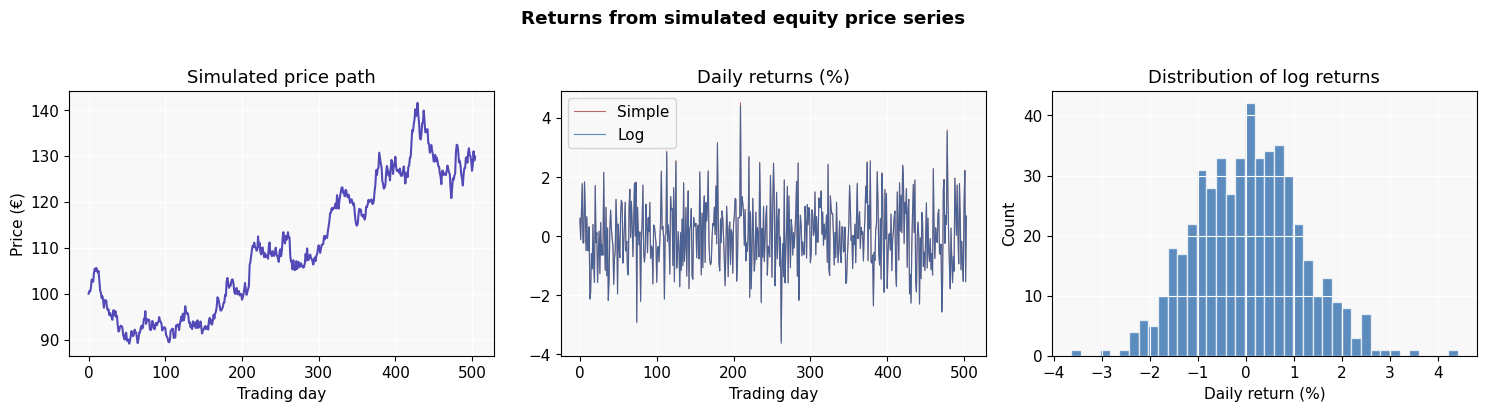

Annualised return : 13.1%
Annualised vol (σ): 17.7%
Simple vs log return (day 1): 0.6047% vs 0.6029%  — nearly identical for small moves


In [3]:
# ── Simulate realistic price series and compute both return types ────────────
np.random.seed(42)
T = 504  # 2 years of trading days

# Parameters for equity-like asset
mu_daily    = 0.10 / 252    # 10% annual return
sigma_daily = 0.18 / np.sqrt(252)  # 18% annual vol

# Generate log returns, reconstruct prices
log_rets  = np.random.normal(mu_daily, sigma_daily, T)
prices    = 100 * np.exp(np.cumsum(log_rets))
prices    = np.concatenate([[100.0], prices])

simple_rets = np.diff(prices) / prices[:-1]
log_rets_v  = np.diff(np.log(prices))

# ── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(prices, color=PURPLE, lw=1.5)
axes[0].set_title('Simulated price path')
axes[0].set_xlabel('Trading day')
axes[0].set_ylabel('Price (€)')

axes[1].plot(simple_rets * 100, color=RED, lw=0.8, alpha=0.7, label='Simple')
axes[1].plot(log_rets_v  * 100, color=BLUE, lw=0.8, alpha=0.7, label='Log')
axes[1].set_title('Daily returns (%)')
axes[1].set_xlabel('Trading day')
axes[1].legend()

axes[2].hist(log_rets_v * 100, bins=40, color=BLUE, alpha=0.7, edgecolor='white')
axes[2].set_title('Distribution of log returns')
axes[2].set_xlabel('Daily return (%)')
axes[2].set_ylabel('Count')

plt.suptitle('Returns from simulated equity price series', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

ann_vol  = log_rets_v.std() * np.sqrt(252) * 100
ann_ret  = log_rets_v.mean() * 252 * 100
print(f'Annualised return : {ann_ret:.1f}%')
print(f'Annualised vol (σ): {ann_vol:.1f}%')
print(f'Simple vs log return (day 1): {simple_rets[0]*100:.4f}% vs {log_rets_v[0]*100:.4f}%  — nearly identical for small moves')

---
## Part 2 — Core Statistics

> **Mean, variance, covariance and correlation are derived in Module 01** ([`01_market_fundamentals.ipynb`](quant_finance_01_market_fundamentals.ipynb)). They are reused here without re-derivation; the object this notebook builds on directly is **portfolio variance**.

### Portfolio variance — the fundamental formula
For a portfolio with weight vector $\mathbf{w}$ and covariance matrix $\Sigma$:
$$\sigma^2_p = \mathbf{w}^\top \Sigma \mathbf{w}$$

For 2 assets:
$$\sigma^2_p = w_1^2\sigma_1^2 + w_2^2\sigma_2^2 + 2w_1 w_2 \rho_{12}\sigma_1\sigma_2$$

The cross-term shrinks when $\rho$ is negative — this is the mathematical definition of **diversification**, and the quantity every optimizer in this notebook minimises.

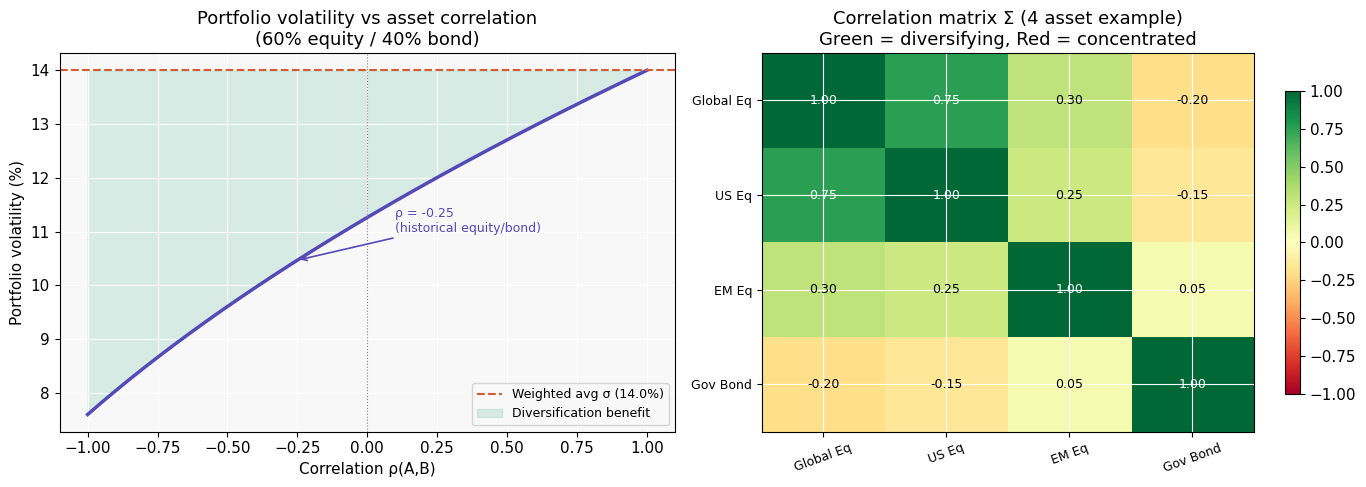

At ρ = -1.0 : portfolio σ = 7.6%
At ρ =  0.0 : portfolio σ = 11.3%
At ρ = +1.0 : portfolio σ = 14.0%  (no diversification benefit)


In [4]:
# ── Diversification demo: portfolio vol vs correlation ──────────────────────
sigma_A, sigma_B = 0.18, 0.08    # annual vols: equity 18%, bond 8%
w_A = 0.60                        # 60/40 portfolio
w_B = 0.40

rho_range   = np.linspace(-1, 1, 200)
port_vol    = np.sqrt(w_A**2*sigma_A**2 + w_B**2*sigma_B**2
                      + 2*w_A*w_B*rho_range*sigma_A*sigma_B)
weighted_avg = w_A*sigma_A + w_B*sigma_B  # upper bound (rho=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: portfolio vol vs correlation
axes[0].plot(rho_range, port_vol * 100, color=PURPLE, lw=2.5)
axes[0].axhline(weighted_avg * 100, color=CORAL, lw=1.5, ls='--', label=f'Weighted avg σ ({weighted_avg*100:.1f}%)')
axes[0].axvline(0, color='gray', lw=0.8, ls=':')
axes[0].fill_between(rho_range, port_vol*100, weighted_avg*100, alpha=0.15, color=TEAL,
                     label='Diversification benefit')
axes[0].set_xlabel('Correlation ρ(A,B)')
axes[0].set_ylabel('Portfolio volatility (%)')
axes[0].set_title('Portfolio volatility vs asset correlation\n(60% equity / 40% bond)')
axes[0].legend(fontsize=9)
axes[0].annotate('ρ = -0.25\n(historical equity/bond)',
                 xy=(-0.25, np.sqrt(w_A**2*sigma_A**2 + w_B**2*sigma_B**2 + 2*w_A*w_B*(-0.25)*sigma_A*sigma_B)*100),
                 xytext=(0.1, 11), fontsize=9, color=PURPLE,
                 arrowprops=dict(arrowstyle='->', color=PURPLE, lw=1.2))

# Right: covariance matrix heatmap for 4 assets
np.random.seed(0)
n = 252
# Simulate 4 correlated assets
corr = np.array([[1.00, 0.75, 0.30, -0.20],
                  [0.75, 1.00, 0.25, -0.15],
                  [0.30, 0.25, 1.00,  0.05],
                  [-0.20,-0.15, 0.05,  1.00]])
vols = np.array([0.18, 0.22, 0.15, 0.06])
Sigma = np.outer(vols, vols) * corr

im = axes[1].imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=axes[1], shrink=0.8)
labels = ['Global Eq', 'US Eq', 'EM Eq', 'Gov Bond']
axes[1].set_xticks(range(4)); axes[1].set_xticklabels(labels, rotation=20, fontsize=9)
axes[1].set_yticks(range(4)); axes[1].set_yticklabels(labels, fontsize=9)
for i in range(4):
    for j in range(4):
        axes[1].text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center', fontsize=9,
                     color='black' if abs(corr[i,j]) < 0.6 else 'white')
axes[1].set_title('Correlation matrix Σ (4 asset example)\nGreen = diversifying, Red = concentrated')

plt.tight_layout()
plt.show()

print(f'At ρ = -1.0 : portfolio σ = {np.sqrt(w_A**2*sigma_A**2+w_B**2*sigma_B**2+2*w_A*w_B*(-1)*sigma_A*sigma_B)*100:.1f}%')
print(f'At ρ =  0.0 : portfolio σ = {np.sqrt(w_A**2*sigma_A**2+w_B**2*sigma_B**2)*100:.1f}%')
print(f'At ρ = +1.0 : portfolio σ = {weighted_avg*100:.1f}%  (no diversification benefit)')

---
## Part 3 — Mean-Variance Optimization (MVO)

Harry Markowitz (Nobel 1990) asked: given expected returns $\boldsymbol{\mu}$ and a covariance matrix $\Sigma$, what portfolio weights $\mathbf{w}$ maximise return for a given level of risk?

### The optimization problem
$$\underset{\mathbf{w}}{\text{maximise}} \quad \mathbf{w}^\top\boldsymbol{\mu} - \frac{\lambda}{2}\,\mathbf{w}^\top\Sigma\mathbf{w}$$
$$\text{subject to} \quad \mathbf{1}^\top\mathbf{w} = 1, \quad w_i \geq 0 \quad \forall\, i$$

$\lambda$ is the **risk-aversion parameter**. Sweeping $\lambda$ from 0 to $\infty$ traces the entire **efficient frontier**.

### Why it is convex
The objective $-\mathbf{w}^\top\boldsymbol{\mu} + \frac{\lambda}{2}\mathbf{w}^\top\Sigma\mathbf{w}$ is convex because $\Sigma$ is **positive semi-definite** (PSD) — all eigenvalues $\geq 0$. Any PSD quadratic form is convex. The constraint set is a convex polytope. Therefore any local minimum is the global minimum — solvers are guaranteed to find it.

### The fundamental problem with μ
The expected return vector $\boldsymbol{\mu}$ is almost impossible to estimate from historical data. With $T=252$ daily observations, the standard error of the mean is $\sigma/\sqrt{T} \approx 18\%/\sqrt{252} \approx 1.1\%$ daily, or about $17\%$ annually — larger than the equity risk premium itself. This is why practitioners either use Black-Litterman, set $\boldsymbol{\mu}$ from equilibrium, or just minimise variance.

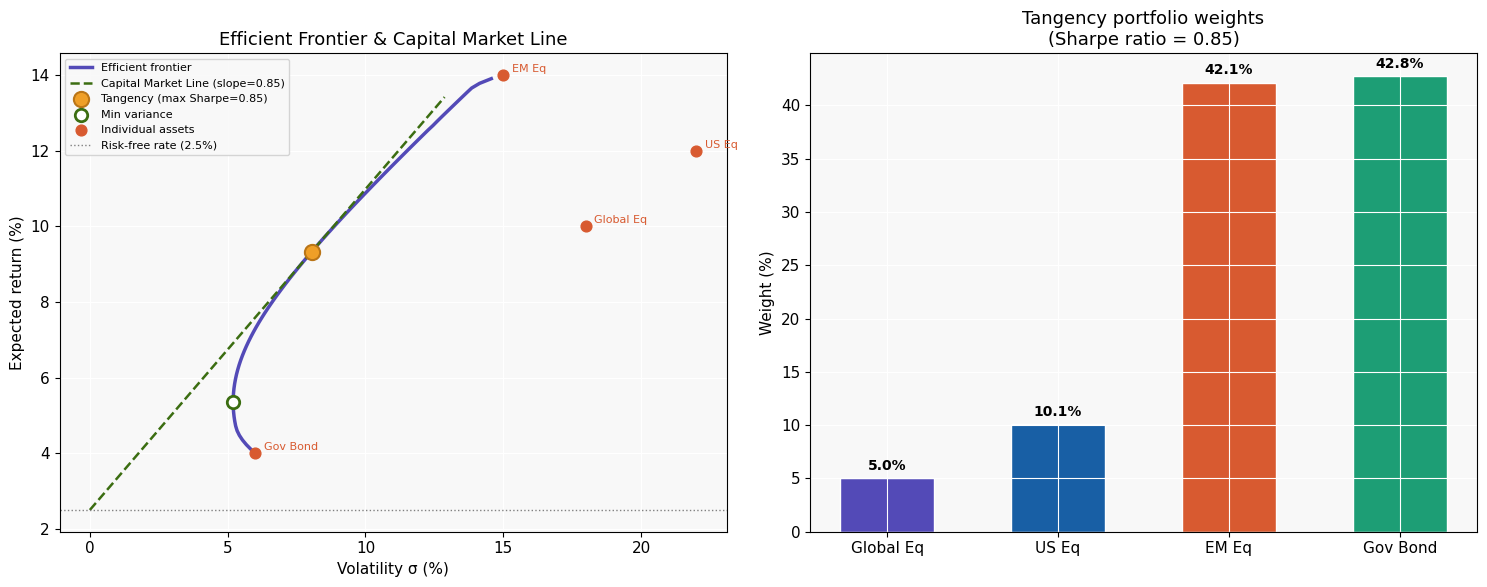

Tangency portfolio:
  Global Eq   : 5.0%
  US Eq       : 10.1%
  EM Eq       : 42.1%
  Gov Bond    : 42.8%
  Return: 9.3%  |  Vol: 8.0%  |  Sharpe: 0.85


In [5]:
# ── Build the efficient frontier for 4 assets ────────────────────────────────
mu  = np.array([0.10, 0.12, 0.14, 0.04])   # annualised expected returns
vols = np.array([0.18, 0.22, 0.15, 0.06])
corr = np.array([[1.00, 0.75, 0.30, -0.20],
                  [0.75, 1.00, 0.25, -0.15],
                  [0.30, 0.25, 1.00,  0.05],
                  [-0.20,-0.15, 0.05,  1.00]])
Sigma = np.outer(vols, vols) * corr
N = len(mu)
rf = 0.025   # risk-free rate

def portfolio_stats(w, mu, Sigma):
    ret = w @ mu
    vol = np.sqrt(w @ Sigma @ w)
    return ret, vol

def neg_sharpe(w, mu, Sigma, rf):
    r, v = portfolio_stats(w, mu, Sigma)
    return -(r - rf) / v

# Sweep target returns to trace efficient frontier
target_rets = np.linspace(mu.min() + 0.001, mu.max() - 0.001, 80)
frontier_vols, frontier_rets = [], []

for target in target_rets:
    constraints = [
        {'type': 'eq', 'fun': lambda w: w.sum() - 1},
        {'type': 'eq', 'fun': lambda w, t=target: w @ mu - t}
    ]
    bounds = [(0, 1)] * N
    w0 = np.ones(N) / N
    res = minimize(lambda w: w @ Sigma @ w, w0, method='SLSQP',
                   bounds=bounds, constraints=constraints)
    if res.success:
        r, v = portfolio_stats(res.x, mu, Sigma)
        frontier_vols.append(v)
        frontier_rets.append(r)

frontier_vols = np.array(frontier_vols)
frontier_rets = np.array(frontier_rets)

# Tangency portfolio (max Sharpe)
res_tangency = minimize(neg_sharpe, np.ones(N)/N, args=(mu, Sigma, rf),
                         method='SLSQP', bounds=[(0,1)]*N,
                         constraints=[{'type': 'eq', 'fun': lambda w: w.sum()-1}])
w_tang = res_tangency.x
r_tang, v_tang = portfolio_stats(w_tang, mu, Sigma)
sr_tang = (r_tang - rf) / v_tang

# Min variance portfolio
res_minvar = minimize(lambda w: w @ Sigma @ w, np.ones(N)/N, method='SLSQP',
                      bounds=[(0,1)]*N,
                      constraints=[{'type': 'eq', 'fun': lambda w: w.sum()-1}])
w_mv = res_minvar.x
r_mv, v_mv = portfolio_stats(w_mv, mu, Sigma)

# Capital Market Line
cml_vols = np.array([0, v_tang * 1.6])
cml_rets = rf + sr_tang * cml_vols

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Efficient frontier
ax = axes[0]
ax.plot(frontier_vols*100, frontier_rets*100, color=PURPLE, lw=2.5, label='Efficient frontier')
ax.plot(cml_vols*100, cml_rets*100, color=GREEN, lw=1.8, ls='--', label=f'Capital Market Line (slope={sr_tang:.2f})')
ax.scatter([v_tang*100], [r_tang*100], s=120, color=AMBER, zorder=5,
           edgecolors='#BA7517', lw=1.5, label=f'Tangency (max Sharpe={sr_tang:.2f})')
ax.scatter([v_mv*100], [r_mv*100], s=80, color='white', zorder=5,
           edgecolors=GREEN, lw=2, label='Min variance')
ax.scatter(vols*100, mu*100, s=60, color=CORAL, zorder=4, label='Individual assets')
asset_names = ['Global Eq', 'US Eq', 'EM Eq', 'Gov Bond']
for i, name in enumerate(asset_names):
    ax.annotate(name, (vols[i]*100, mu[i]*100), textcoords='offset points',
                xytext=(6, 2), fontsize=8, color=CORAL)
ax.axhline(rf*100, color='gray', lw=1, ls=':', label=f'Risk-free rate ({rf*100:.1f}%)')
ax.set_xlabel('Volatility σ (%)')
ax.set_ylabel('Expected return (%)')
ax.set_title('Efficient Frontier & Capital Market Line')
ax.legend(fontsize=8)

# Right: Tangency portfolio weights
ax2 = axes[1]
colors_bar = [PURPLE, BLUE, CORAL, TEAL]
bars = ax2.bar(asset_names, w_tang * 100, color=colors_bar, edgecolor='white', width=0.55)
ax2.set_ylabel('Weight (%)')
ax2.set_title(f'Tangency portfolio weights\n(Sharpe ratio = {sr_tang:.2f})')
for bar, w in zip(bars, w_tang):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{w*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print('Tangency portfolio:')
for name, w in zip(asset_names, w_tang):
    print(f'  {name:12s}: {w*100:.1f}%')
print(f'  Return: {r_tang*100:.1f}%  |  Vol: {v_tang*100:.1f}%  |  Sharpe: {sr_tang:.2f}')

---
## Part 4 — CAPM and the Security Market Line

> **CAPM theory, the SML derivation and its critique are in Module 02** ([`02_risk_measures_mpt.ipynb`](quant_finance_02_risk_measures_mpt.ipynb)). Here we *apply* CAPM: computing betas and reverse-engineering equilibrium returns to use as the prior for Black-Litterman.

If every investor optimises as Markowitz describes, what equilibrium must prevail? The **Capital Asset Pricing Model** answers this.

**Key insight:** In equilibrium, every investor holds the market portfolio. Risk that can be diversified away earns no premium. Only **systematic risk** (co-movement with the market) is compensated.

### Beta — systematic risk
$$\beta_i = \frac{\text{Cov}(r_i, r_{mkt})}{\text{Var}(r_{mkt})} = \rho_{i,mkt} \cdot \frac{\sigma_i}{\sigma_{mkt}}$$

### The Security Market Line (SML)
$$E[r_i] = r_f + \beta_i \cdot \underbrace{(E[r_{mkt}] - r_f)}_{\text{equity risk premium}}$$

### Reverse-engineered equilibrium returns
If we know the market portfolio weights $\mathbf{w}_{mkt}$ and the market's aggregate risk aversion $\delta$, we can back out implied expected returns — the foundation of Black-Litterman:
$$\boldsymbol{\Pi} = \delta \cdot \Sigma \cdot \mathbf{w}_{mkt}$$

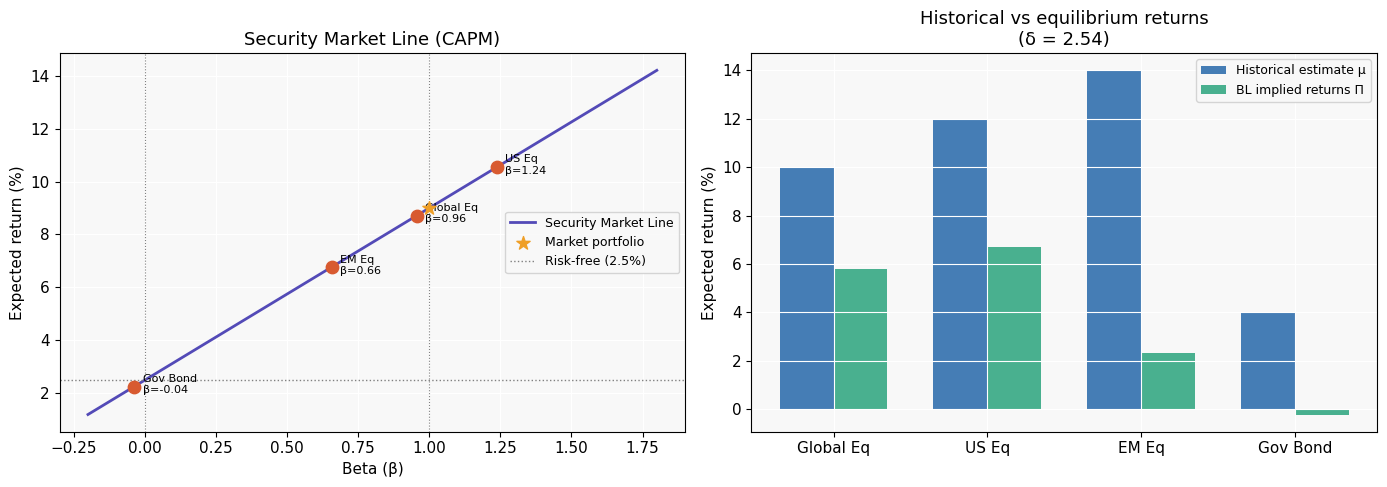

Aggregate risk aversion δ = (μ_mkt - rf) / σ²_mkt = 2.54

Equilibrium implied returns Π = δ·Σ·w_mkt:
  Global Eq   : 5.81%
  US Eq       : 6.70%
  EM Eq       : 2.32%
  Gov Bond    : -0.22%


In [6]:
# ── CAPM: compute betas and plot the Security Market Line ────────────────────
sigma_mkt = 0.16      # market volatility
mu_mkt    = 0.09      # market expected return
rf        = 0.025
erp       = mu_mkt - rf   # equity risk premium = 6.5%

# Individual assets: correlation with market
rho_mkt  = np.array([0.85, 0.90, 0.70, -0.10])   # correlations with market
betas    = rho_mkt * (vols / sigma_mkt)
capm_rets = rf + betas * erp

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Security Market Line
beta_range = np.linspace(-0.2, 1.8, 100)
sml_rets   = rf + beta_range * erp

axes[0].plot(beta_range, sml_rets*100, color=PURPLE, lw=2, label='Security Market Line')
axes[0].scatter(betas, capm_rets*100, s=80, color=CORAL, zorder=5)
for i, name in enumerate(asset_names):
    axes[0].annotate(f'{name}\nβ={betas[i]:.2f}', (betas[i], capm_rets[i]*100),
                     textcoords='offset points', xytext=(6, -5), fontsize=8)
axes[0].scatter([1], [mu_mkt*100], s=100, color=AMBER, zorder=5, marker='*', label='Market portfolio')
axes[0].axhline(rf*100, color='gray', lw=1, ls=':', label=f'Risk-free ({rf*100:.1f}%)')
axes[0].axvline(0, color='gray', lw=0.8, ls=':')
axes[0].axvline(1, color='gray', lw=0.8, ls=':')
axes[0].set_xlabel('Beta (β)')
axes[0].set_ylabel('Expected return (%)')
axes[0].set_title('Security Market Line (CAPM)')
axes[0].legend(fontsize=9)

# Right: Equilibrium implied returns
w_mkt_eq  = np.array([0.45, 0.25, 0.15, 0.15])  # market weights
delta     = (mu_mkt - rf) / (sigma_mkt**2)        # aggregate risk aversion ≈ 2.5
Pi        = delta * Sigma @ w_mkt_eq               # implied returns

x = np.arange(N)
width = 0.35
axes[1].bar(x - width/2, mu*100,  width, color=BLUE,  label='Historical estimate μ', alpha=0.8)
axes[1].bar(x + width/2, Pi*100, width, color=TEAL, label='BL implied returns Π', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(asset_names)
axes[1].set_ylabel('Expected return (%)')
axes[1].set_title(f'Historical vs equilibrium returns\n(δ = {delta:.2f})')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Aggregate risk aversion δ = (μ_mkt - rf) / σ²_mkt = {delta:.2f}')
print('\nEquilibrium implied returns Π = δ·Σ·w_mkt:')
for name, pi_val in zip(asset_names, Pi):
    print(f'  {name:12s}: {pi_val*100:.2f}%')

---
## Part 5 — Black-Litterman Model

Black-Litterman (1990) solves the instability of raw MVO by combining market equilibrium returns with analyst views in a Bayesian framework.

### The four steps

**Step 1 — Prior:** Start from equilibrium returns $\boldsymbol{\Pi} = \delta\,\Sigma\,\mathbf{w}_{mkt}$

**Step 2 — Views:** Express $K$ views via pick matrix $\mathbf{P}$ (K×N), view returns $\mathbf{Q}$ (K×1), uncertainty $\Omega$ (K×K diagonal)

**Step 3 — Posterior (Bayesian update):**
$$\boldsymbol{\mu}_{BL} = \left[(\tau\Sigma)^{-1} + \mathbf{P}^\top\Omega^{-1}\mathbf{P}\right]^{-1} \left[(\tau\Sigma)^{-1}\boldsymbol{\Pi} + \mathbf{P}^\top\Omega^{-1}\mathbf{Q}\right]$$

**Step 4 — Optimise** using $\boldsymbol{\mu}_{BL}$ instead of historical $\boldsymbol{\mu}$

The posterior is just the standard Gaussian update formula — the matrix inverse weights prior and view precisions against each other. High view confidence (small $\Omega_{kk}$) → posterior is pulled strongly toward that view.

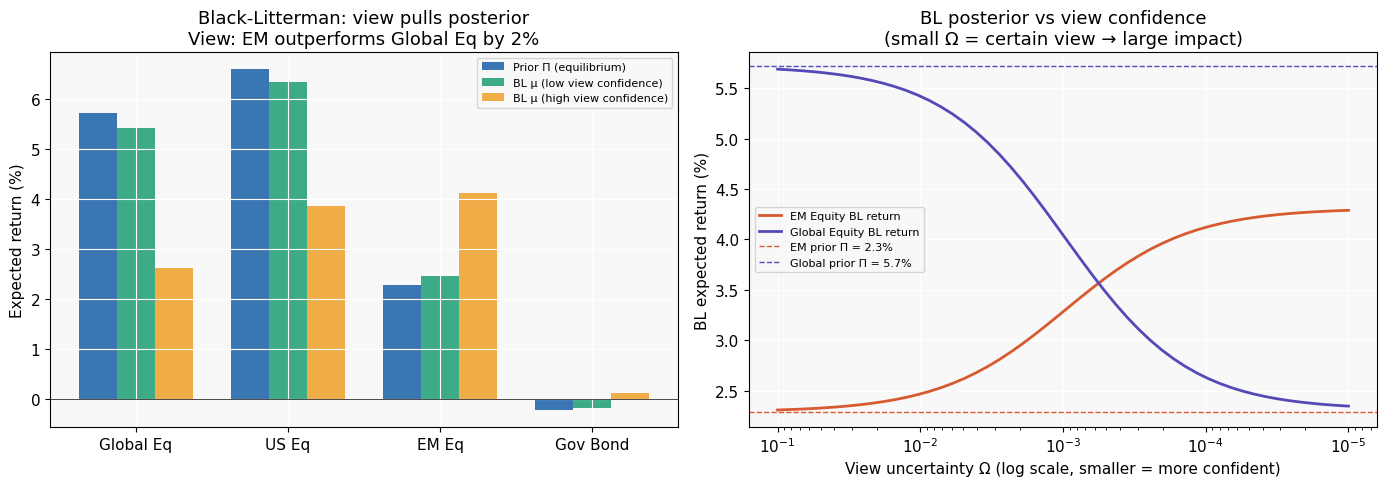

In [8]:
# ── Black-Litterman implementation ────────────────────────────────────────────
def black_litterman(w_mkt, Sigma, P, Q, Omega, delta=2.5, tau=0.025):
    """
    Compute Black-Litterman posterior expected returns.
    
    Parameters
    ----------
    w_mkt  : (N,) market portfolio weights
    Sigma  : (N,N) covariance matrix
    P      : (K,N) pick matrix (view loadings)
    Q      : (K,) view expected returns
    Omega  : (K,K) view uncertainty (diagonal)
    delta  : market risk aversion
    tau    : uncertainty in prior (typically 0.025)
    """
    Pi           = delta * Sigma @ w_mkt          # equilibrium returns
    prior_prec   = np.linalg.inv(tau * Sigma)     # (τΣ)⁻¹
    view_prec    = P.T @ np.linalg.inv(Omega) @ P # P'Ω⁻¹P
    post_cov     = np.linalg.inv(prior_prec + view_prec)
    post_mean    = post_cov @ (prior_prec @ Pi + P.T @ np.linalg.inv(Omega) @ Q)
    return post_mean, Pi

# Market setup
w_mkt  = np.array([0.45, 0.25, 0.15, 0.15])
delta  = 2.5
tau    = 0.025

# View: "EM Equities will outperform Global Equities by 2% annually"
P     = np.array([[-1, 0, 1, 0]])   # long EM, short Global Eq
Q     = np.array([0.02])            # 2% outperformance
Omega_high_conf = np.array([[0.0001]])  # high confidence in view
Omega_low_conf  = np.array([[0.0100]])  # low confidence in view

mu_bl_high, Pi = black_litterman(w_mkt, Sigma, P, Q, Omega_high_conf)
mu_bl_low, _   = black_litterman(w_mkt, Sigma, P, Q, Omega_low_conf)

# ── Plot: how view confidence pulls posterior toward view ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(N)
width = 0.25
axes[0].bar(x - width,   Pi*100,          width, color=BLUE,   label='Prior Π (equilibrium)', alpha=0.85)
axes[0].bar(x,            mu_bl_low*100,   width, color=TEAL,   label='BL μ (low view confidence)', alpha=0.85)
axes[0].bar(x + width,   mu_bl_high*100,  width, color=AMBER,  label='BL μ (high view confidence)', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(asset_names)
axes[0].set_ylabel('Expected return (%)')
axes[0].set_title('Black-Litterman: view pulls posterior\nView: EM outperforms Global Eq by 2%')
axes[0].legend(fontsize=8)
axes[0].axhline(0, color='black', lw=0.5)

# Right: posterior sensitivity to view confidence
confidence_range = np.logspace(-5, -1, 50)  # Omega values
em_bl_rets = []
global_bl_rets = []
for omega_val in confidence_range:
    Omega_v = np.array([[omega_val]])
    mu_bl_v, _ = black_litterman(w_mkt, Sigma, P, Q, Omega_v)
    em_bl_rets.append(mu_bl_v[2] * 100)      # EM equity
    global_bl_rets.append(mu_bl_v[0] * 100)  # Global equity

axes[1].semilogx(confidence_range, em_bl_rets,     color=CORAL,  lw=2, label='EM Equity BL return')
axes[1].semilogx(confidence_range, global_bl_rets, color=PURPLE, lw=2, label='Global Equity BL return')
axes[1].axhline(Pi[2]*100, color=CORAL,  lw=1, ls='--', label=f'EM prior Π = {Pi[2]*100:.1f}%')
axes[1].axhline(Pi[0]*100, color=PURPLE, lw=1, ls='--', label=f'Global prior Π = {Pi[0]*100:.1f}%')
axes[1].set_xlabel('View uncertainty Ω (log scale, smaller = more confident)')
axes[1].set_ylabel('BL expected return (%)')
axes[1].set_title('BL posterior vs view confidence\n(small Ω = certain view → large impact)')
axes[1].legend(fontsize=8)
axes[1].invert_xaxis()

plt.tight_layout()
plt.show()

---
## Part 6 — Covariance Estimation: Ledoit-Wolf and Factor Models

### The problem with sample covariance
With $N=50$ assets and $T=252$ daily observations, you have 1,275 parameters from 252 observations. The matrix is **ill-conditioned** — small eigenvalues get estimated as near-zero, their inverses explode, and the optimizer exploits estimation error.

### Ledoit-Wolf shrinkage
Shrink the sample covariance toward a structured target $F$:
$$\hat{\Sigma} = (1-\alpha)\,\Sigma_{sample} + \alpha\,F$$

The optimal $\alpha$ is chosen analytically to minimise expected squared estimation error. In Python: `sklearn.covariance.LedoitWolf`.

### Factor model decomposition
Model returns through $K \ll N$ factors:
$$r_i = \alpha_i + \sum_j \beta_{ij}F_j + \varepsilon_i \quad \Rightarrow \quad \Sigma = B\,F_{cov}B^\top + D$$

Total parameters: $K^2 + NK + N$ vs $N(N+1)/2$ for the full matrix. For $N=50$, $K=5$: 325 vs 1,275.

In [ ]:
# ── Ledoit-Wolf vs sample covariance: stability comparison ───────────────────
np.random.seed(42)
N_big = 30    # 30 assets
T_big = 252   # 1 year daily data  — T/N = 8.4, borderline

# True covariance: factor model structure
K = 3
B_true = np.random.randn(N_big, K) * 0.1   # factor loadings
F_true = np.diag([0.04, 0.01, 0.005])      # factor variances
D_true = np.diag(np.random.uniform(0.005, 0.02, N_big))  # idiosyncratic
Sigma_true = B_true @ F_true @ B_true.T + D_true

# Simulate returns from true Sigma
L = np.linalg.cholesky(Sigma_true)
returns_sim = (np.random.randn(T_big, N_big) @ L.T)

# Estimate covariance: three methods
Sigma_sample = np.cov(returns_sim.T)
lw = LedoitWolf().fit(returns_sim)
Sigma_lw     = lw.covariance_
alpha_lw     = lw.shrinkage_

# Measure estimation error (Frobenius norm)
def frob_error(S_est, S_true):
    return np.linalg.norm(S_est - S_true, 'fro') / np.linalg.norm(S_true, 'fro')

err_sample = frob_error(Sigma_sample, Sigma_true)
err_lw     = frob_error(Sigma_lw,     Sigma_true)

# Eigenvalue comparison (small eigenvalues → ill-conditioned matrix)
eigs_true   = np.sort(np.linalg.eigvalsh(Sigma_true))[::-1]
eigs_sample = np.sort(np.linalg.eigvalsh(Sigma_sample))[::-1]
eigs_lw     = np.sort(np.linalg.eigvalsh(Sigma_lw))[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Eigenvalue spectrum
axes[0].semilogy(eigs_true,   'o-', color=GREEN,  lw=2, ms=4, label='True Σ')
axes[0].semilogy(eigs_sample, 's-', color=CORAL,  lw=1.5, ms=4, label=f'Sample Σ (err={err_sample:.2f})')
axes[0].semilogy(eigs_lw,     '^-', color=BLUE,   lw=1.5, ms=4, label=f'Ledoit-Wolf Σ (err={err_lw:.2f})')
axes[0].set_xlabel('Eigenvalue rank')
axes[0].set_ylabel('Eigenvalue (log scale)')
axes[0].set_title(f'Eigenvalue spectrum: {N_big} assets, {T_big} obs\nLedoit-Wolf shrinkage α = {alpha_lw:.3f}')
axes[0].legend(fontsize=9)
axes[0].annotate('Sample Σ: small eigenvalues\nnear zero → Σ⁻¹ explodes',
                 xy=(25, eigs_sample[-1]), fontsize=8, color=CORAL,
                 xytext=(15, 0.001), arrowprops=dict(arrowstyle='->', color=CORAL))

# Frobenius error as T/N ratio varies
T_ratios  = [1, 2, 3, 5, 8, 10, 15, 20]
errs_samp, errs_lw_v = [], []
for ratio in T_ratios:
    T_v = ratio * N_big
    rets_v = (np.random.randn(T_v, N_big) @ L.T)
    Sv = np.cov(rets_v.T)
    errs_samp.append(frob_error(Sv, Sigma_true))
    lw_v = LedoitWolf().fit(rets_v)
    errs_lw_v.append(frob_error(lw_v.covariance_, Sigma_true))

axes[1].plot(T_ratios, errs_samp, 'o-', color=CORAL,  lw=2, label='Sample covariance')
axes[1].plot(T_ratios, errs_lw_v, '^-', color=BLUE,   lw=2, label='Ledoit-Wolf')
axes[1].axvline(8.4, color='gray', lw=1, ls='--', label='Current T/N = 8.4')
axes[1].set_xlabel('T/N ratio (observations per asset)')
axes[1].set_ylabel('Relative Frobenius error')
axes[1].set_title('Estimation error vs data availability\nLedoit-Wolf wins when T/N is small')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Relative estimation error — Sample: {err_sample:.3f} | Ledoit-Wolf: {err_lw:.3f}')
print(f'Ledoit-Wolf shrinkage intensity α = {alpha_lw:.3f}  (0 = no shrinkage, 1 = full shrinkage to identity)')

---
## Part 7 — Risk Measures Beyond Volatility

Volatility assumes normality. Real returns are fat-tailed and negatively skewed — crashes are larger and more frequent than the normal distribution predicts.

### Value at Risk (VaR)
$$\text{VaR}_\alpha = \text{quantile}(\text{losses}, \alpha)$$
"With 95% confidence, we won't lose more than VaR₉₅ in one day." **Fatal flaw:** VaR is NOT sub-additive — diversification can appear to increase risk.

### CVaR / Expected Shortfall (ES)
$$\text{CVaR}_\alpha = E[\text{loss} \mid \text{loss} > \text{VaR}_\alpha] = \frac{1}{1-\alpha}\int_\alpha^1 \text{VaR}_u\,du$$
The **average** of the worst $(1-\alpha)\%$ of outcomes. CVaR is sub-additive (coherent), and crucially **convex in portfolio weights** — it can be directly minimised in cvxpy.

### Sharpe Ratio
$$\text{SR} = \frac{E[R_p] - r_f}{\sigma_p}$$
Return per unit of total risk. The tangency portfolio maximises the Sharpe ratio.

In [ ]:
# ── VaR and CVaR: normal vs fat-tailed returns ───────────────────────────────
np.random.seed(42)
T_sim = 10000

# Normal returns
mu_d, sig_d = 0.0004, 0.012
rets_normal = np.random.normal(mu_d, sig_d, T_sim)

# Fat-tailed: Student-t with 4 degrees of freedom (matches empirical equity returns)
from scipy.stats import t as t_dist
df = 4
rets_fat = t_dist.rvs(df, loc=mu_d, scale=sig_d * np.sqrt((df-2)/df), size=T_sim)

alpha = 0.95

def compute_var_cvar(rets, alpha):
    sorted_rets = np.sort(rets)
    var_idx = int((1 - alpha) * len(rets))
    var = -sorted_rets[var_idx]
    cvar = -sorted_rets[:var_idx].mean()
    return var, cvar

var_n, cvar_n = compute_var_cvar(rets_normal, alpha)
var_f, cvar_f = compute_var_cvar(rets_fat,   alpha)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, rets, title, var, cvar, color in [
    (axes[0], rets_normal, 'Normal distribution', var_n, cvar_n, BLUE),
    (axes[1], rets_fat,    'Fat-tailed (Student-t, df=4)', var_f, cvar_f, CORAL)
]:
    counts, bins, _ = ax.hist(rets*100, bins=100, color=color, alpha=0.5, edgecolor='none',
                              density=True, label='Return distribution')
    # Shade the tail
    tail_mask = bins[:-1] < -var*100
    ax.bar(bins[:-1][tail_mask], counts[tail_mask],
           width=np.diff(bins)[tail_mask], color=RED, alpha=0.7,
           align='edge', label=f'Tail (worst {(1-alpha)*100:.0f}%)')
    ax.axvline(-var*100,  color=AMBER, lw=2, ls='--', label=f'VaR₉₅ = {var*100:.2f}%')
    ax.axvline(-cvar*100, color=RED,   lw=2, ls='-',  label=f'CVaR₉₅ = {cvar*100:.2f}%')
    ax.set_xlabel('Daily return (%)')
    ax.set_ylabel('Density')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('VaR vs CVaR: why fat tails matter for risk management', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print('95% risk measures (daily):')
print(f'              VaR₉₅     CVaR₉₅')
print(f'Normal:       {var_n*100:.2f}%     {cvar_n*100:.2f}%')
print(f'Fat-tailed:   {var_f*100:.2f}%     {cvar_f*100:.2f}%')
print(f'\nCVaR is larger than VaR: it tells you what to expect when the VaR threshold is breached.')
print(f'CVaR fat-tail / normal = {cvar_f/cvar_n:.2f}x — fat tails make losses significantly worse in the tail.')

---
## Part 8 — Risk Budgeting and Risk Parity

Instead of optimising return per unit of total risk, **risk budgeting** allocates a target *risk budget* to each asset.

### Risk contribution
The risk contribution of asset $i$ is:
$$RC_i = w_i \cdot \frac{(\Sigma\mathbf{w})_i}{\sigma_p}$$

Note: $\sum_i RC_i = \sigma_p$ — risk contributions partition total portfolio volatility.

### Risk parity portfolio
Equalise all risk contributions: $RC_i = RC_j \;\forall\, i,j$.

This produces much more balanced portfolios than MVO. A naïve 60/40 portfolio has ~90% of its risk in equities (because equity vol is 3× bond vol). Risk parity gives bonds much more weight to equalise contributions — effectively a levered bond position. This is the backbone of many robo-advisor target portfolios.

In [ ]:
# ── Risk contributions and risk parity ───────────────────────────────────────
def risk_contributions(w, Sigma):
    """Compute each asset's contribution to total portfolio volatility."""
    port_vol = np.sqrt(w @ Sigma @ w)
    mrc = Sigma @ w / port_vol          # marginal risk contribution
    rc  = w * mrc                        # total risk contribution
    return rc, port_vol

def risk_parity_objective(w, Sigma):
    """Minimise sum of squared differences in risk contributions."""
    rc, _ = risk_contributions(w, Sigma)
    target = np.ones(len(w)) / len(w)   # equal risk budget
    rc_norm = rc / rc.sum()              # normalise to fractions
    return np.sum((rc_norm - target)**2)

# Solve for risk parity
res_rp = minimize(
    risk_parity_objective, np.ones(N)/N, args=(Sigma,),
    method='SLSQP',
    bounds=[(0.01, 1.0)]*N,
    constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
)
w_rp = res_rp.x

w_naive = np.array([0.60, 0.15, 0.10, 0.15])  # 60% equity tilt

portfolios = {'Naive 60/40-like': w_naive, 'Risk Parity': w_rp, 'Tangency (MVO)': w_tang}
colors_p = [CORAL, TEAL, AMBER]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (pname, w_p) in enumerate(portfolios.items()):
    rc, pv = risk_contributions(w_p, Sigma)
    rc_pct = rc / pv * 100   # as % of total vol

    # Weights
    bars = axes[0].bar(
        np.arange(N) + idx*0.25, w_p*100, 0.24,
        color=colors_p[idx], label=pname, alpha=0.85
    )
    # Risk contributions
    axes[1].bar(
        np.arange(N) + idx*0.25, rc_pct, 0.24,
        color=colors_p[idx], label=pname, alpha=0.85
    )

# Risk contribution to total vol (donut-style bar)
rc_naive, pv_naive = risk_contributions(w_naive, Sigma)
rc_rp_v, pv_rp    = risk_contributions(w_rp, Sigma)
pv_naive_pct = rc_naive / pv_naive
pv_rp_pct    = rc_rp_v  / pv_rp

x = np.arange(N)
axes[2].bar(x - 0.2, pv_naive_pct*100, 0.38, color=CORAL, label='Naive portfolio', alpha=0.85)
axes[2].bar(x + 0.2, pv_rp_pct*100,   0.38, color=TEAL,  label='Risk parity', alpha=0.85)
axes[2].axhline(25, color='gray', lw=1.5, ls='--', label='Equal (25% each)')

axes[0].set_xticks(np.arange(N)+0.25); axes[0].set_xticklabels(asset_names)
axes[0].set_ylabel('Weight (%)'); axes[0].set_title('Portfolio weights')
axes[0].legend(fontsize=8)

axes[1].set_xticks(np.arange(N)+0.25); axes[1].set_xticklabels(asset_names)
axes[1].set_ylabel('Risk contribution (% of total vol)')
axes[1].set_title('Risk contributions by asset')
axes[1].legend(fontsize=8)

axes[2].set_xticks(x); axes[2].set_xticklabels(asset_names)
axes[2].set_ylabel('% of total portfolio risk')
axes[2].set_title('Risk parity equalises contributions\n(each asset = 25% of risk)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print('\nNaive portfolio risk concentrations:')
for name, rc in zip(asset_names, rc_naive/pv_naive*100):
    bar = '█' * int(rc/2)
    print(f'  {name:12s}: {rc:.1f}%  {bar}')
print(f'  Total vol: {pv_naive*100:.1f}%')
print('\nRisk parity portfolio:')
for name, rc, w in zip(asset_names, rc_rp_v/pv_rp*100, w_rp*100):
    bar = '█' * int(rc/2)
    print(f'  {name:12s}: RC={rc:.1f}%  w={w:.1f}%  {bar}')
print(f'  Total vol: {pv_rp*100:.1f}%')

---
## Summary: The Mental Model

You are solving a **constrained optimization problem** where:

| Component | Mathematical object | Practical challenge |
|---|---|---|
| Decision variables | Portfolio weights **w** | Must sum to 1, stay non-negative |
| Objective | Return (linear) minus risk (quadratic) | Convex → global optimum guaranteed |
| Return input μ | Expected return vector | Nearly impossible to estimate reliably → use Black-Litterman |
| Risk input Σ | Covariance matrix | Estimable but noisy → use Ledoit-Wolf or factor models |
| Risk measure | w'Σw (variance) or CVaR | CVaR handles fat tails and is convex |
| Solver | cvxpy + OSQP | Finds global optimum in milliseconds |

The entire discipline of quantitative portfolio management is making this pipeline work reliably in production — with noisy data, changing market regimes, client-specific constraints, and regulatory requirements.

**Key equations to have cold:**

$$\sigma^2_p = \mathbf{w}^\top \Sigma \mathbf{w} \qquad \text{(portfolio variance)}$$

$$\text{SR} = \frac{E[R_p] - r_f}{\sigma_p} \qquad \text{(Sharpe ratio)}$$

$$E[r_i] = r_f + \beta_i(E[r_{mkt}]-r_f) \qquad \text{(CAPM)}$$

$$\boldsymbol{\mu}_{BL} = \left[(\tau\Sigma)^{-1} + \mathbf{P}^\top\Omega^{-1}\mathbf{P}\right]^{-1}\left[(\tau\Sigma)^{-1}\boldsymbol{\Pi} + \mathbf{P}^\top\Omega^{-1}\mathbf{Q}\right] \qquad \text{(Black-Litterman)}$$

$$RC_i = w_i \cdot \frac{(\Sigma\mathbf{w})_i}{\sigma_p} \qquad \text{(risk contribution)}$$